In [40]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [63]:
#Initializing dataset and printing some columns
df = pd.read_csv(r"DAV Mini Project Data/StudentPerformanceFactors.csv")
print(df.head(5))
print(df.loc[df["Parental_Education_Level"].isna()])

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [64]:
#Getting some basic info of our dataset
print(df.info())

#Number of attributes and total number of records
print("Number of attributes : ", df.shape[0])
print("Total number of records : ", df.shape[1])

#Attributes we will be focusing on
print("Attributes we will be focusing on:")
print("Hours_Studied\tAttendance\tSleep_Hours\tPrevious_Scores\tMotivation_Level\tExtracuricular Activities")
print("Family_Income\tExam_score")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [65]:
#Storing the number of Null Values
tqnull = df["Teacher_Quality"].isnull().sum()
pelnull = df["Parental_Education_Level"].isnull().sum()
dfh = df["Distance_from_Home"].isnull().sum()

In [66]:
#DATA PREPROCESSING

print("Number of Null Values:")
print("Teacher_Quality : ", tqnull)
print("Parental_Education_Level : ", pelnull)
print("Distance_from_Home : ", dfh)

#Plugging in median values for Null Values for normalized data
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna("Uneducated")
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

Number of Null Values:
Teacher_Quality :  78
Parental_Education_Level :  90
Distance_from_Home :  67


In [67]:
#Cleaning up and streamlining text in the dataset
#Extra spaces to be removed
textcolumns = df.select_dtypes(include=["object", "string"]).columns
df[textcolumns] = df[textcolumns].apply(lambda x: x.str.strip())

#Standardizing the columns (uppercase first character, lowercase rest of the characters)
specificcol = ["School_Type", "Motivation_Level"]
df[specificcol] = df[specificcol].apply(lambda x: x.str.title())

#Changing motivational level values for it to look better while graphing
mlchange = {"Low":"Low Motivation", "Medium":"Medium Motivation", "High":"High Motivation"}
df["Motivation_Level"] = df["Motivation_Level"].replace(mlchange)

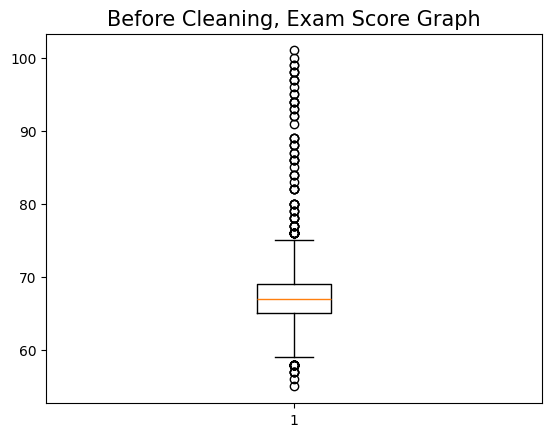

The box plot clearly displays presence of a huge number of outliers in the exam score data
These extreme values affects the accuracy of the analysis and distorts results
Hence, cleaning the dataset of these outliers is required to make it more reliable


In [68]:
#Finding outliers using boxplotting

plt.boxplot(df["Exam_Score"])
plt.title("Before Cleaning, Exam Score Graph", fontsize=15)
plt.show()

print("The box plot clearly displays presence of a huge number of outliers in the exam score data")
print("These extreme values affects the accuracy of the analysis and distorts results")
print("Hence, cleaning the dataset of these outliers is required to make it more reliable")

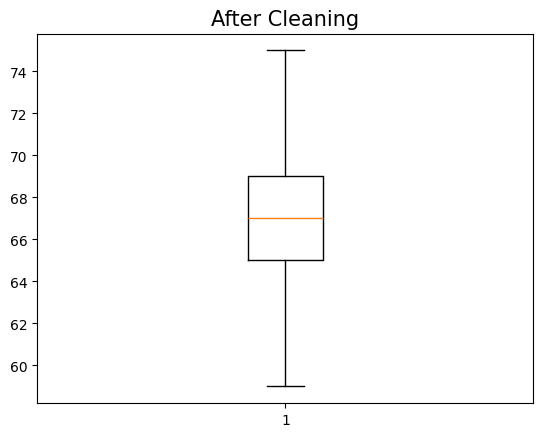

The box plot showcases that the 'Exam_Score' column has been correctly cleaned


In [72]:
#Removing outliers using the IQR method
q1 = df["Exam_Score"].quantile(0.25)
q3 = df["Exam_Score"].quantile(0.75)
iqr = q3-q1
lower = q1 - (iqr*1.5)
upper = q3 + (iqr*1.5)
avg = int(df["Exam_Score"].mean())
df.loc[(df["Exam_Score"]<lower) | (df["Exam_Score"]>upper), "Exam_Score"] = avg

#Boxplotting to check if the "Exam_Score" column has been cleaned
plt.boxplot(df["Exam_Score"])
plt.title("After Cleaning", fontsize=15)
plt.show()

print(r"The box plot showcases that the 'Exam_Score' column has been correctly cleaned")

In [78]:
#New parameter to measure student performance
print("We create a new column that calculates the studying efficiency from the number of hours studied and the exam score")
df["StudyingEfficiency"] = df["Exam_Score"]/df["Hours_Studied"] * 100
df.head()

We create a new column that calculates the studying efficiency from the number of hours studied and the exam score


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,StudyingEfficiency
0,23,84,Low,High,No,7,73,Low Motivation,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67.0,291.304348
1,19,64,Low,Medium,No,8,59,Low Motivation,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61.0,321.052632
2,24,98,Medium,Medium,Yes,7,91,Medium Motivation,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74.0,308.333333
3,29,89,Low,Medium,Yes,8,98,Medium Motivation,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71.0,244.827586
4,19,92,Medium,Medium,Yes,6,65,Medium Motivation,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70.0,368.421053


In [79]:
#Attendance Grouping

attgrp = [0, 50, 75, 85, 100]
labels = ["Low", "Moderate", "Good", "Excellent"]
df["Attendance Level"] = pd.cut(df["Attendance"], bins = attgrp, labels = labels, right = False)

print("A new column with attendance rating has been created")
print (df.head(5))

A new column with attendance rating has been created
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores   Motivation_Level  \
0                         No            7               73     Low Motivation   
1                         No            8               59     Low Motivation   
2                        Yes            7               91  Medium Motivation   
3                        Yes            8               98  Medium Motivation   
4                        Yes            6               65  Medium Motivation   

  Internet_Access  Tu

In [86]:
#Describing the numerical columns
numclm = df.select_dtypes(include=["number"])
aggr = numclm.describe()
aggr.drop(["count"])
print("Statistical Summary")
aggr

Statistical Summary


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,StudyingEfficiency
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.072727,380.590035
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.221908,226.760377
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,59.000000,156.361998
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000,283.333333
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000,335.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000,412.500000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,75.000000,6723.565915


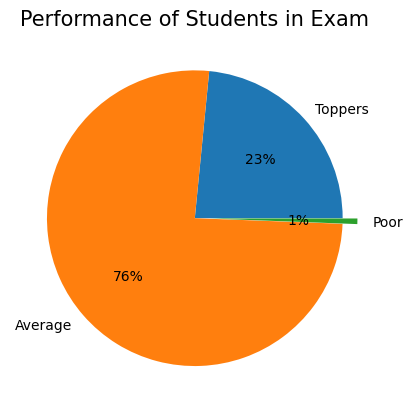

In [141]:
#Score Distribution
greaterthan70 = df.loc[df["Exam_Score"] >= 70, "Exam_Score"].count()
greaterthan60 = df.loc[(df["Exam_Score"] >= 60) & (df["Exam_Score"] < 70), "Exam_Score"].count()
lessthan60 = df.loc[df["Exam_Score"] < 60, "Exam_Score"].count()

plt.pie([greaterthan70, greaterthan60, lessthan60], labels=["Toppers", "Average", "Poor"], explode=[0, 0, 0.1], autopct="%.0f%%")
plt.title("Performance of Students in Exam", fontsize=15)
plt.show()

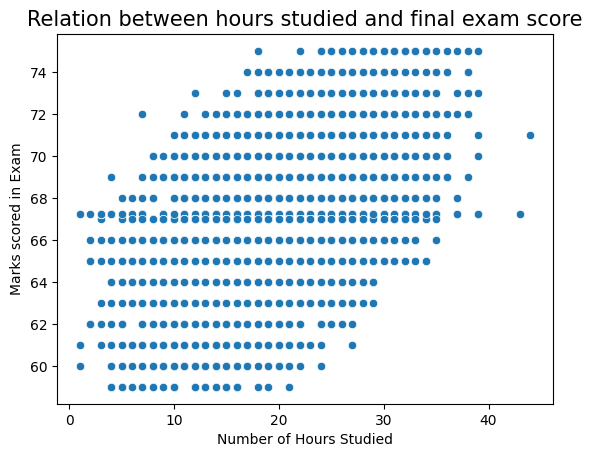

By the scatterplot, its clearly visible that more hours studied directly translates to more marks scored in exam
Student must stay consistent in these hours to achieve academic success


In [140]:
#Hours vs Score
sns.scatterplot(data = df, x = "Hours_Studied", y = "Exam_Score")
plt.xlabel("Number of Hours Studied")
plt.ylabel("Marks scored in Exam")
plt.title("Relation between hours studied and final exam score", fontsize = 15)
plt.show()

print("By the scatterplot, its clearly visible that more hours studied directly translates to more marks scored in exam")
print("Student must stay consistent in these hours to achieve academic success")

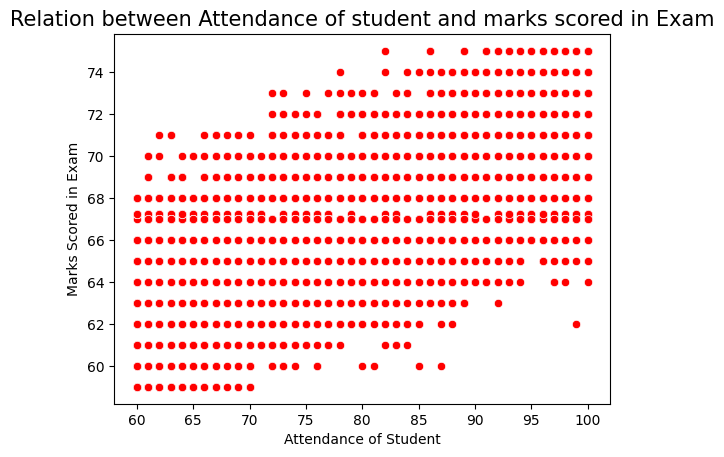

Clearly, attending more classes is extremely benficial for the student
Most of the students above 70 marks have above 75% attendance
Attend classes, get more marks


In [95]:
#Attendance vs Score
sns.scatterplot(data = df, x="Attendance", y = "Exam_Score", color="red")
plt.xlabel("Attendance of Student")
plt.ylabel("Marks Scored in Exam")
plt.title("Relation between Attendance of student and marks scored in Exam", fontsize=15)
plt.show()

print("Clearly, attending more classes is extremely benficial for the student")
print("Most of the students above 70 marks have above 75% attendance")
print("Attend classes, get more marks")

Text(0.5, 1.0, 'Relation between number of hours slept and marks scored in exam')

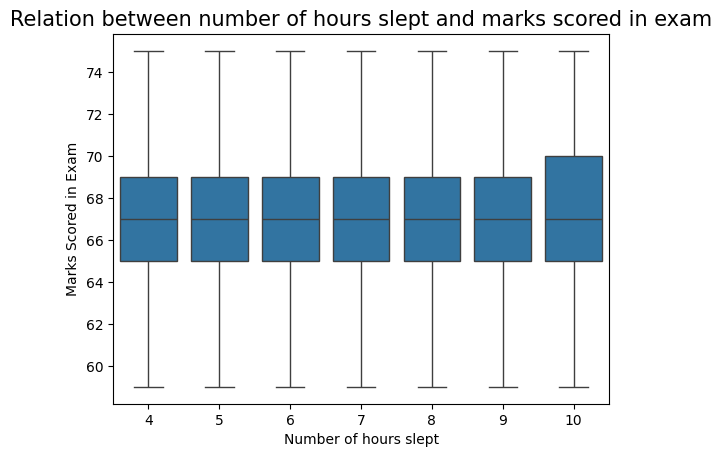

In [92]:
#Hours slept vs Marks scored
sns.boxplot(data = df, x = "Sleep_Hours", y = "Exam_Score")
plt.xlabel("Number of hours slept")
plt.ylabel("Marks Scored in Exam")
plt.title("Relation between number of hours slept and marks scored in exam", fontsize=15)

print("No direct correlation seems visible between sleeping hours and marks scored in the exam")
print("However there is one outlier, sleeping for 10 hours seems to have a marginally higher range of marks")

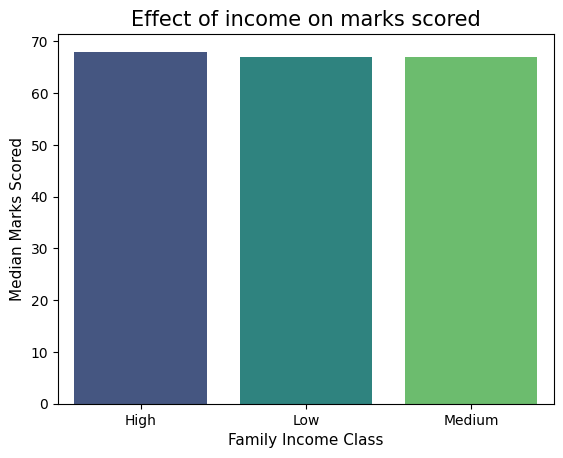

Contrary to expectations, all three income groups seem to fare equally in the exams
Students from higher income families seem to have a slight edge over other students


In [103]:
# Income vs Score
incomegroup = df.groupby("Family_Income")["Exam_Score"].median().reset_index()
sns.barplot(data=incomegroup, x="Family_Income", y="Exam_Score", hue="Family_Income", palette="viridis")
plt.title("Effect of income on marks scored", fontsize=15)
plt.xlabel("Family Income Class", fontsize=11)
plt.ylabel("Median Marks Scored", fontsize=11)
plt.show()

print("Contrary to expectations, all three income groups seem to fare equally in the exams")
print("Students from higher income families seem to have a slight edge over other students")

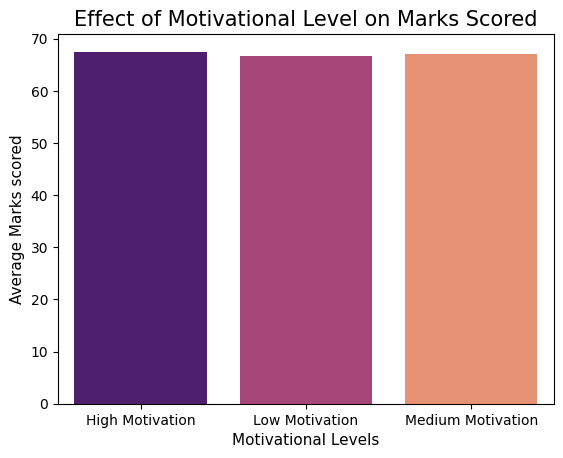

In [104]:
# Motivation vs Score
mlscores = df.groupby("Motivation_Level")["Exam_Score"].mean().reset_index()
sns.barplot(data=mlscores, x="Motivation_Level", y="Exam_Score", hue="Motivation_Level", palette = "magma")
plt.title("Effect of Motivational Level on Marks Scored", fontsize=15)
plt.xlabel("Motivational Levels", fontsize=11)
plt.ylabel("Average Marks scored", fontsize=11)
plt.show()

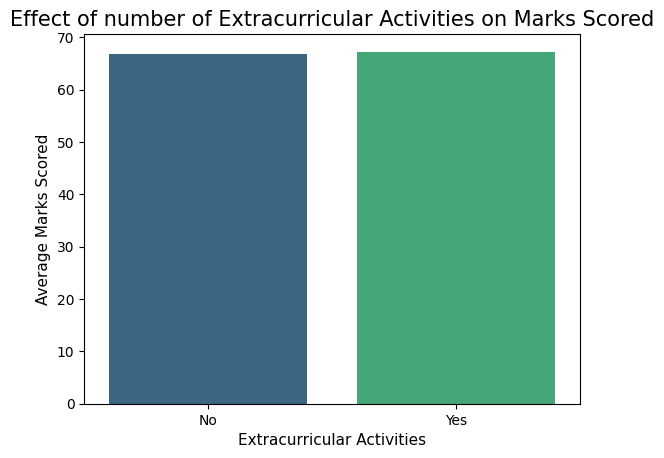

The graph shows us a rather confusing picture, as on average a student is able to score higher with an extracurricular activity that would reduce the number of hours studied
However the difference is very marginal


In [109]:
# Activities vs Score
ccascores = df.groupby("Extracurricular_Activities")["Exam_Score"].mean().reset_index()
sns.barplot(data=ccascores, x="Extracurricular_Activities", y="Exam_Score", hue="Extracurricular_Activities", palette="viridis")
plt.title("Effect of number of Extracurricular Activities on Marks Scored", fontsize=15)
plt.xlabel("Extracurricular Activities", fontsize=11)
plt.ylabel("Average Marks Scored", fontsize=11)
plt.show()

print("The graph shows us a rather confusing picture, as on average a student is able to score higher with an extracurricular activity that would reduce the number of hours studied")
print("However the difference is very marginal")

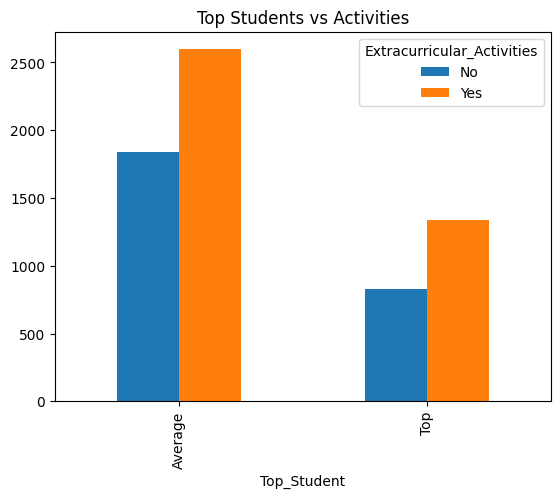

In [110]:
# Top Students vs Activities
threshold = df["Exam_Score"].quantile(0.75)

df["Top_Student"] = df["Exam_Score"].apply(
    lambda x: "Top" if x >= threshold else "Average"
)

df.groupby(["Top_Student","Extracurricular_Activities"]).size().unstack().plot(kind='bar')

plt.title("Top Students vs Activities")
plt.show()

print("There are far more students with extra activities than students without")
print("There are more students in the top category with extra activities")
print("This is able to paint a clearer picture than the previous analysis telling us that extra activities positively impact studying")

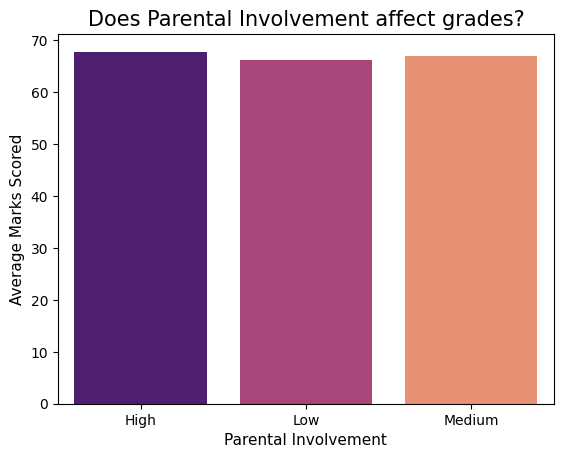

Students with higher parental involvement tend to score better.


In [115]:
# ANALYSIS -> PARENTAL INVOLVEMENT

piscores = df.groupby("Parental_Involvement")["Exam_Score"].mean().reset_index()
sns.barplot(data=piscores, x="Parental_Involvement", y="Exam_Score", hue="Parental_Involvement", palette="magma")
plt.title("Does Parental Involvement affect grades?", fontsize=15)
plt.xlabel("Parental Involvement", fontsize=11)
plt.ylabel("Average Marks Scored", fontsize=11)
plt.show()

print("Students with higher parental involvement tend to score better.")

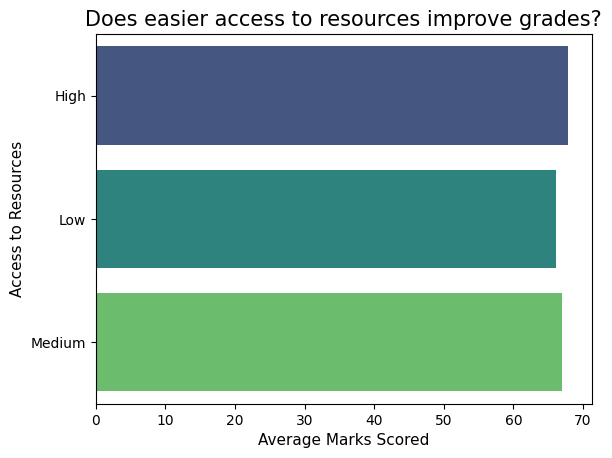

Better access to resources leads to improved academic performance.


In [118]:
# ANALYSIS -> ACCESS TO RESOURCES

arscores = df.groupby("Access_to_Resources")["Exam_Score"].mean().reset_index()
sns.barplot(data=arscores, y="Access_to_Resources", x="Exam_Score", hue="Access_to_Resources", palette="viridis", orient="h")
plt.title("Does easier access to resources improve grades?", fontsize=15)
plt.ylabel("Access to Resources", fontsize=11)
plt.xlabel("Average Marks Scored", fontsize=11)
plt.show()

print("Better access to resources leads to improved academic performance.")

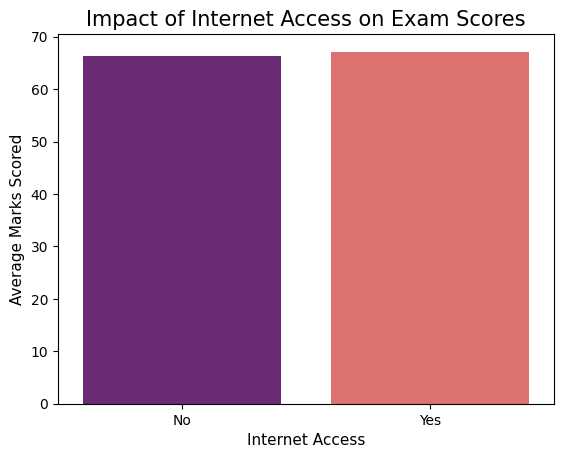

Students with internet access tend to perform better.


In [121]:
# ANALYSIS -> INTERNET ACCESS
iascores = df.groupby("Internet_Access")["Exam_Score"].mean().reset_index()
sns.barplot(data=iascores, x="Internet_Access", y="Exam_Score", hue="Internet_Access", palette="magma")
plt.title("Impact of Internet Access on Exam Scores", fontsize=15)
plt.xlabel("Internet Access", fontsize=11)
plt.ylabel("Average Marks Scored", fontsize=11)
plt.show()
print("Students with internet access tend to perform better.")

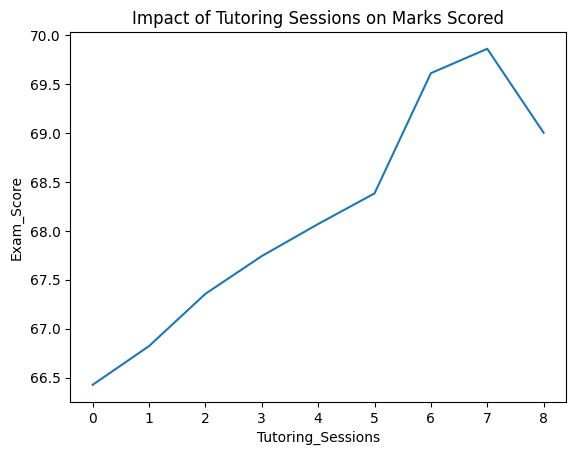

Students attending tutoring sessions perform better.


In [145]:
# ANALYSIS -> TUTORING SESSIONS
tsscores = df.groupby("Tutoring_Sessions")["Exam_Score"].mean().reset_index()
sns.lineplot(data=tsscores, x="Tutoring_Sessions", y="Exam_Score")
plt.title("Impact of Tutoring Sessions on Marks Scored")
plt.show()
print("Students attending tutoring sessions perform better.")
print("However attending excessive hours of tutoring ses